<a href="https://colab.research.google.com/github/xysu129/deep-learning-ust-2026/blob/main/All_3_Experiments_EarlyStop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Transfer Learning for Breast Ultrasound Segmentation
## All 3 Experiments with Early Stopping


In [ ]:
!pip -q install kagglehub

import os, numpy as np, tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import VGG16
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from PIL import Image
import warnings; warnings.filterwarnings('ignore')

IMG_SIZE = 128
BATCH_SIZE = 16
EPOCHS = 50  # higher max since early stopping will cut it short

print("TF:", tf.__version__, "| GPU:", tf.config.list_physical_devices('GPU'))


TF: 2.19.0 | GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# ============================================================
# Load BUSI dataset
# ============================================================
import kagglehub
busi_path = kagglehub.dataset_download("aryashah2k/breast-ultrasound-images-dataset")

images, masks = [], []
for category in ['benign', 'malignant']:
    for root, dirs, files in os.walk(busi_path):
        if os.path.basename(root).lower() == category:
            img_files = sorted([f for f in os.listdir(root) if f.endswith('.png') and '_mask' not in f])
            for img_file in img_files:
                mask_path = os.path.join(root, img_file.replace('.png', '_mask.png'))
                if not os.path.exists(mask_path): continue
                img = Image.open(os.path.join(root, img_file)).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
                images.append(np.array(img) / 255.0)
                mask = Image.open(mask_path).convert('L').resize((IMG_SIZE, IMG_SIZE))
                masks.append((np.array(mask) / 255.0 > 0.5).astype(np.float32))
            break

images = np.array(images, dtype=np.float32)
masks = np.array(masks, dtype=np.float32)[..., np.newaxis]
X_train, X_temp, y_train, y_temp = train_test_split(images, masks, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)
print(f"BUSI: {len(images)} images | Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")


Using Colab cache for faster access to the 'breast-ultrasound-images-dataset' dataset.
BUSI: 647 images | Train: 452, Val: 97, Test: 98


In [ ]:
# ============================================================
# Model building blocks, loss, metrics, early stopping callback
# ============================================================
def conv_block(x, filters):
    x = layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    return x

def build_unet_scratch(input_shape=(IMG_SIZE, IMG_SIZE, 3)):
    inputs = layers.Input(shape=input_shape)
    c1 = conv_block(inputs, 32); p1 = layers.MaxPooling2D(2)(c1)
    c2 = conv_block(p1, 64);    p2 = layers.MaxPooling2D(2)(c2)
    c3 = conv_block(p2, 128);   p3 = layers.MaxPooling2D(2)(c3)
    c4 = conv_block(p3, 256);   p4 = layers.MaxPooling2D(2)(c4)
    c5 = conv_block(p4, 512)
    u6 = layers.Concatenate()([layers.Conv2DTranspose(256, 2, strides=2, padding='same')(c5), c4]); c6 = conv_block(u6, 256)
    u7 = layers.Concatenate()([layers.Conv2DTranspose(128, 2, strides=2, padding='same')(c6), c3]); c7 = conv_block(u7, 128)
    u8 = layers.Concatenate()([layers.Conv2DTranspose(64, 2, strides=2, padding='same')(c7), c2]);  c8 = conv_block(u8, 64)
    u9 = layers.Concatenate()([layers.Conv2DTranspose(32, 2, strides=2, padding='same')(c8), c1]);  c9 = conv_block(u9, 32)
    outputs = layers.Conv2D(1, 1, activation='sigmoid')(c9)
    return keras.Model(inputs, outputs)

def build_unet_vgg16(input_shape=(IMG_SIZE, IMG_SIZE, 3), weights='imagenet'):
    base = VGG16(weights=weights, include_top=False, input_shape=input_shape)
    s1 = base.get_layer('block1_conv2').output
    s2 = base.get_layer('block2_conv2').output
    s3 = base.get_layer('block3_conv3').output
    s4 = base.get_layer('block4_conv3').output
    b  = base.get_layer('block5_conv3').output
    u6 = layers.Concatenate()([layers.Conv2DTranspose(512, 2, strides=2, padding='same')(b), s4]);  c6 = conv_block(u6, 512)
    u7 = layers.Concatenate()([layers.Conv2DTranspose(256, 2, strides=2, padding='same')(c6), s3]); c7 = conv_block(u7, 256)
    u8 = layers.Concatenate()([layers.Conv2DTranspose(128, 2, strides=2, padding='same')(c7), s2]); c8 = conv_block(u8, 128)
    u9 = layers.Concatenate()([layers.Conv2DTranspose(64, 2, strides=2, padding='same')(c8), s1]);  c9 = conv_block(u9, 64)
    outputs = layers.Conv2D(1, 1, activation='sigmoid')(c9)
    return keras.Model(base.input, outputs), base

def dice_coeff(y_true, y_pred, smooth=1.0):
    y_true_f = tf.reshape(y_true, [-1]); y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1 - dice_coeff(y_true, y_pred)

def bce_dice_loss(y_true, y_pred):
    return keras.losses.binary_crossentropy(y_true, y_pred) + dice_loss(y_true, y_pred)

def iou_metric(y_true, y_pred):
    y_pred = tf.cast(y_pred > 0.5, tf.float32)
    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) - intersection
    return (intersection + 1e-7) / (union + 1e-7)

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=7, restore_best_weights=True, verbose=1
)
print("All helpers ready.")


All helpers ready.


In [ ]:
# ============================================================
# EXPERIMENT A: U-Net from scratch + Early Stopping
# ============================================================
print("=" * 50)
print("EXPERIMENT A: U-Net from scratch")
print("=" * 50)

model_A = build_unet_scratch()
model_A.compile(optimizer=keras.optimizers.Adam(1e-3), loss=bce_dice_loss, metrics=[dice_coeff, iou_metric])

history_A = model_A.fit(
    X_train, y_train, validation_data=(X_val, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=[early_stop], verbose=1
)
print(f"Stopped at epoch {len(history_A.history['loss'])}")


EXPERIMENT A: U-Net from scratch
Epoch 1/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 71s 1s/step - dice_coeff: 0.2425 - iou_metric: 0.2295 - loss: 1.3946 - val_dice_coeff: 0.1524 - val_iou_metric: 0.0921 - val_loss: 17.0048
Epoch 2/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 92ms/step - dice_coeff: 0.3167 - iou_metric: 0.4168 - loss: 1.1536 - val_dice_coeff: 0.1443 - val_iou_metric: 0.0805 - val_loss: 130.7375
Epoch 3/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 92ms/step - dice_coeff: 0.3545 - iou_metric: 0.4471 - loss: 1.0352 - val_dice_coeff: 0.1364 - val_iou_metric: 0.0744 - val_loss: 251.3384
Epoch 4/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - dice_coeff: 0.4152 - iou_metric: 0.4834 - loss: 0.9137 - val_dice_coeff: 0.2445 - val_iou_metric: 0.1552 - val_loss: 8.4787
Epoch 5/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 94ms/step - dice_coeff: 0.4594 - iou_metric: 0.5042 - loss: 0.8188 - val_dice_coeff: 0.1247 - val_iou_metric: 0.0726 - val_loss: 7.0957
Epoch 6/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step - dice_coeff: 0.5218 - iou_

In [ ]:
# ============================================================
# EXPERIMENT B: VGG16 ImageNet + Early Stopping
# ============================================================
print("=" * 50)
print("EXPERIMENT B: VGG16 ImageNet backbone")
print("=" * 50)

model_B, _ = build_unet_vgg16(weights='imagenet')

# Phase 1: freeze encoder
for layer in model_B.layers:
    if 'block' in layer.name: layer.trainable = False
model_B.compile(optimizer=keras.optimizers.Adam(1e-3), loss=bce_dice_loss, metrics=[dice_coeff, iou_metric])

early_stop_B1 = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
history_B1 = model_B.fit(X_train, y_train, validation_data=(X_val, y_val),
                         epochs=15, batch_size=BATCH_SIZE, callbacks=[early_stop_B1], verbose=1)

# Phase 2: unfreeze all
for layer in model_B.layers: layer.trainable = True
model_B.compile(optimizer=keras.optimizers.Adam(1e-4), loss=bce_dice_loss, metrics=[dice_coeff, iou_metric])

early_stop_B2 = keras.callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1)
history_B2 = model_B.fit(X_train, y_train, validation_data=(X_val, y_val),
                         epochs=EPOCHS, batch_size=BATCH_SIZE, callbacks=[early_stop_B2], verbose=1)
print(f"Phase 1: {len(history_B1.history['loss'])} epochs | Phase 2: {len(history_B2.history['loss'])} epochs")


EXPERIMENT B: VGG16 ImageNet backbone
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - dice_coeff: 0.3115 - iou_metric: 0.3520 - loss: 1.2439 - val_dice_coeff: 0.1479 - val_iou_metric: 0.0773 - val_loss: 122.3713
Epoch 2/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 196ms/step - dice_coeff: 0.4614 - iou_metric: 0.5210 - loss: 0.8626 - val_dice_coeff: 0.4860 - val_iou_metric: 0.3876 - val_loss: 6.8375
Epoch 3/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 200ms/step - dice_coeff: 0.5738 - iou_metric: 0.5955 - loss: 0.6380 - val_dice_coeff: 0.5987 - val_iou_metric: 0.4780 - val_loss: 1.8621
Epoch 4/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 200ms/step - dice_coeff: 0.6486 - iou_metric: 0.6168 - loss: 0.5296 - val_dice_coeff: 0.5209 - val_iou_metric: 0.3858 - val_loss: 3.4665
Epoch 5/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 202ms/step - dice_coeff: 0.6841 - iou_metric: 0.6419 - loss: 0.4671 - val_dice_coeff: 0.6040 - val_iou_metric: 0.4651 - val_loss: 1.5021
Epoch 6/15
29/29 ━━━━

In [ ]:
# ============================================================
# EXPERIMENT C — Step 1: Pretrain encoder on ISIC 2019
# ============================================================
print("=" * 50)
print("EXPERIMENT C: ISIC 2019 Pretrain → BUSI Fine-tune")
print("=" * 50)

# Download ISIC 2019
isic_path = kagglehub.dataset_download("salviohexia/isic-2019-skin-lesion-images-for-classification")

# Load ISIC classification data
def load_isic2019(base_path, img_size=IMG_SIZE, max_per_class=1500):
    images, labels, class_names = [], [], []
    train_dir = None
    for root, dirs, files in os.walk(base_path):
        if len(dirs) >= 4:
            for d in dirs[:3]:
                if any(f.endswith(('.jpg','.png')) for f in os.listdir(os.path.join(root, d))):
                    train_dir = root; break
            if train_dir: break
    class_dirs = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])
    for ci, cn in enumerate(class_dirs):
        cp = os.path.join(train_dir, cn)
        fs = [f for f in os.listdir(cp) if f.endswith(('.jpg','.png'))]
        np.random.seed(42)
        if len(fs) > max_per_class: fs = list(np.random.choice(fs, max_per_class, replace=False))
        print(f"  {cn}: {len(fs)} images")
        class_names.append(cn)
        for f in fs:
            try:
                img = Image.open(os.path.join(cp, f)).convert('RGB').resize((img_size, img_size))
                images.append(np.array(img)/255.0); labels.append(ci)
            except: continue
    return np.array(images, dtype=np.float32), np.array(labels), class_names

isic_imgs, isic_labels, class_names = load_isic2019(isic_path)
isic_Xt, isic_Xv, isic_yt, isic_yv = train_test_split(isic_imgs, isic_labels, test_size=0.15, random_state=42, stratify=isic_labels)
print(f"\nISIC: {len(isic_imgs)} images, {len(class_names)} classes | Train: {len(isic_Xt)}, Val: {len(isic_Xv)}")


EXPERIMENT C: ISIC 2019 Pretrain → BUSI Fine-tune
Using Colab cache for faster access to the 'isic-2019-skin-lesion-images-for-classification' dataset.
  AK: 867 images
  BCC: 1500 images
  BKL: 1500 images
  DF: 239 images
  MEL: 1500 images
  NV: 1500 images
  SCC: 628 images
  VASC: 253 images

ISIC: 7987 images, 8 classes | Train: 6788, Val: 1199


In [ ]:
# ============================================================
# Pretrain VGG16 encoder on ISIC classification (2-phase)
# ============================================================
num_classes = len(class_names)

base_enc = VGG16(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_enc.trainable = False  # freeze for phase 1

x = base_enc.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
out = layers.Dense(num_classes, activation='softmax')(x)
classifier = keras.Model(base_enc.input, out)

# Phase 1: frozen encoder, train classification head
classifier.compile(optimizer=keras.optimizers.Adam(1e-3), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
print("Phase 1: Training classification head (encoder frozen)...")
hist_p1 = classifier.fit(isic_Xt, isic_yt, validation_data=(isic_Xv, isic_yv),
                         epochs=5, batch_size=32, verbose=1)

# Phase 2: unfreeze, lower lr
base_enc.trainable = True
classifier.compile(optimizer=keras.optimizers.Adam(1e-4), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
print("\nPhase 2: Fine-tuning all layers...")
es_pretrain = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
hist_p2 = classifier.fit(isic_Xt, isic_yt, validation_data=(isic_Xv, isic_yv),
                         epochs=15, batch_size=32, callbacks=[es_pretrain], verbose=1)

base_enc.save_weights('isic_encoder.weights.h5')
print(f"\nISIC pretrain done! Final val accuracy: {hist_p2.history['val_accuracy'][-1]:.4f}")


Phase 1: Training classification head (encoder frozen)...
Epoch 1/5
213/213 ━━━━━━━━━━━━━━━━━━━━ 33s 116ms/step - accuracy: 0.3076 - loss: 1.8201 - val_accuracy: 0.4012 - val_loss: 1.6497
Epoch 2/5
213/213 ━━━━━━━━━━━━━━━━━━━━ 17s 80ms/step - accuracy: 0.3707 - loss: 1.6730 - val_accuracy: 0.4178 - val_loss: 1.5805
Epoch 3/5
213/213 ━━━━━━━━━━━━━━━━━━━━ 17s 78ms/step - accuracy: 0.3857 - loss: 1.6273 - val_accuracy: 0.4479 - val_loss: 1.5239
Epoch 4/5
213/213 ━━━━━━━━━━━━━━━━━━━━ 17s 78ms/step - accuracy: 0.4020 - loss: 1.5976 - val_accuracy: 0.4487 - val_loss: 1.5092
Epoch 5/5
213/213 ━━━━━━━━━━━━━━━━━━━━ 17s 79ms/step - accuracy: 0.4035 - loss: 1.5681 - val_accuracy: 0.4470 - val_loss: 1.4873

Phase 2: Fine-tuning all layers...
Epoch 1/15
213/213 ━━━━━━━━━━━━━━━━━━━━ 80s 232ms/step - accuracy: 0.3166 - loss: 1.7831 - val_accuracy: 0.3244 - val_loss: 1.6679
Epoch 2/15
213/213 ━━━━━━━━━━━━━━━━━━━━ 44s 205ms/step - accuracy: 0.3817 - loss: 1.6132 - val_accuracy: 0.4078 - val_loss: 1.538

In [ ]:
# ============================================================
# EXPERIMENT C — Step 2: Fine-tune on BUSI with ISIC encoder
# ============================================================
model_C, base_C = build_unet_vgg16(weights=None)
base_C.load_weights('isic_encoder.weights.h5')
print("Loaded ISIC pretrained encoder!")

# Phase 1: freeze encoder
for layer in model_C.layers:
    if 'block' in layer.name: layer.trainable = False
model_C.compile(optimizer=keras.optimizers.Adam(1e-3), loss=bce_dice_loss, metrics=[dice_coeff, iou_metric])

early_stop_C1 = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
history_C1 = model_C.fit(X_train, y_train, validation_data=(X_val, y_val),
                         epochs=15, batch_size=BATCH_SIZE, callbacks=[early_stop_C1], verbose=1)

# Phase 2: unfreeze all
for layer in model_C.layers: layer.trainable = True
model_C.compile(optimizer=keras.optimizers.Adam(1e-4), loss=bce_dice_loss, metrics=[dice_coeff, iou_metric])

early_stop_C2 = keras.callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1)
history_C2 = model_C.fit(X_train, y_train, validation_data=(X_val, y_val),
                         epochs=EPOCHS, batch_size=BATCH_SIZE, callbacks=[early_stop_C2], verbose=1)
print(f"Phase 1: {len(history_C1.history['loss'])} epochs | Phase 2: {len(history_C2.history['loss'])} epochs")


Loaded ISIC pretrained encoder!
Epoch 1/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 27s 532ms/step - dice_coeff: 0.2937 - iou_metric: 0.3173 - loss: 1.2641 - val_dice_coeff: 0.1358 - val_iou_metric: 0.0738 - val_loss: 135.5255
Epoch 2/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 199ms/step - dice_coeff: 0.3764 - iou_metric: 0.4273 - loss: 0.9998 - val_dice_coeff: 0.2661 - val_iou_metric: 0.1683 - val_loss: 22.3418
Epoch 3/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 203ms/step - dice_coeff: 0.4681 - iou_metric: 0.5046 - loss: 0.8301 - val_dice_coeff: 0.3236 - val_iou_metric: 0.2114 - val_loss: 14.3834
Epoch 4/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 206ms/step - dice_coeff: 0.5020 - iou_metric: 0.4968 - loss: 0.7499 - val_dice_coeff: 0.3811 - val_iou_metric: 0.2614 - val_loss: 12.6246
Epoch 5/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 208ms/step - dice_coeff: 0.5569 - iou_metric: 0.5153 - loss: 0.6513 - val_dice_coeff: 0.4214 - val_iou_metric: 0.2951 - val_loss: 4.0213
Epoch 6/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 210ms/step - dice_coeff: 0.6223

In [ ]:
# ============================================================
# TEST SET EVALUATION — All 3 experiments
# ============================================================
print("\n" + "=" * 60)
print("TEST SET EVALUATION (with Early Stopping)")
print("=" * 60)

results = {}
for name, model in [('A: Scratch', model_A), ('B: ImageNet', model_B), ('C: ISIC Pretrain', model_C)]:
    loss, dice, iou = model.evaluate(X_test, y_test, verbose=0)
    results[name] = {'loss': loss, 'dice': dice, 'iou': iou}
    print(f"{name:20s} | Dice: {dice:.4f} | IoU: {iou:.4f} | Loss: {loss:.4f}")



TEST SET EVALUATION (with Early Stopping)
A: Scratch           | Dice: 0.6721 | IoU: 0.5293 | Loss: 0.5874
B: ImageNet          | Dice: 0.7014 | IoU: 0.5750 | Loss: 0.5218
C: ISIC Pretrain     | Dice: 0.6639 | IoU: 0.5229 | Loss: 0.6085


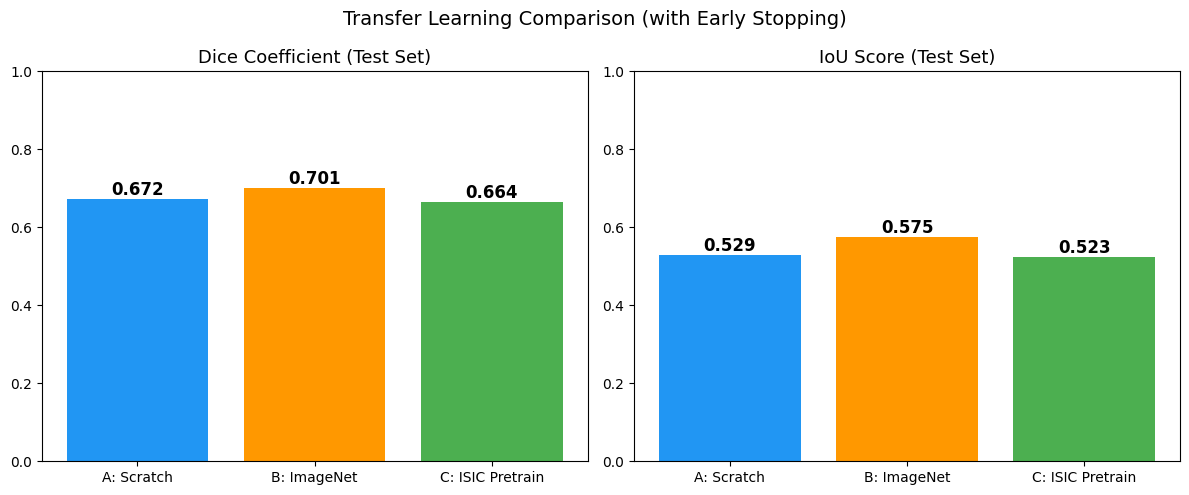

In [ ]:
# ============================================================
# Comparison bar chart
# ============================================================
names = list(results.keys())
dice_scores = [results[n]['dice'] for n in names]
iou_scores = [results[n]['iou'] for n in names]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['#2196F3', '#FF9800', '#4CAF50']

axes[0].bar(names, dice_scores, color=colors)
axes[0].set_title('Dice Coefficient (Test Set)', fontsize=13)
axes[0].set_ylim(0, 1)
for i, v in enumerate(dice_scores):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold', fontsize=12)

axes[1].bar(names, iou_scores, color=colors)
axes[1].set_title('IoU Score (Test Set)', fontsize=13)
axes[1].set_ylim(0, 1)
for i, v in enumerate(iou_scores):
    axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold', fontsize=12)

plt.suptitle('Transfer Learning Comparison (with Early Stopping)', fontsize=14)
plt.tight_layout(); plt.show()


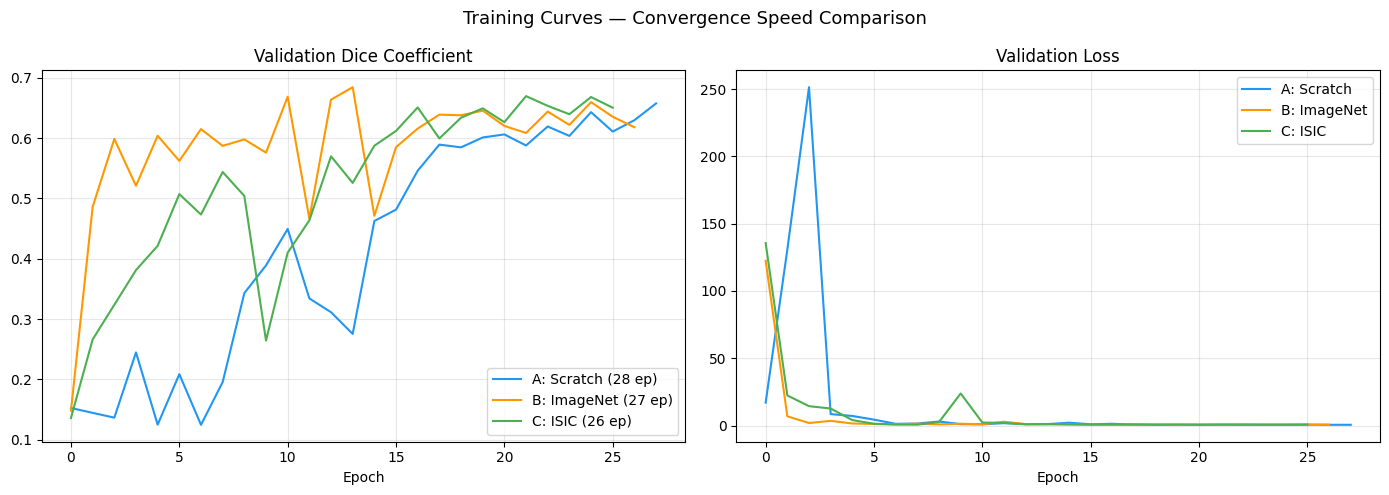

In [ ]:
# ============================================================
# Training curves — convergence speed comparison
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Dice curves
dice_A = history_A.history['val_dice_coeff']
dice_B = history_B1.history['val_dice_coeff'] + history_B2.history['val_dice_coeff']
dice_C = history_C1.history['val_dice_coeff'] + history_C2.history['val_dice_coeff']

axes[0].plot(dice_A, label=f'A: Scratch ({len(dice_A)} ep)', color='#2196F3')
axes[0].plot(dice_B, label=f'B: ImageNet ({len(dice_B)} ep)', color='#FF9800')
axes[0].plot(dice_C, label=f'C: ISIC ({len(dice_C)} ep)', color='#4CAF50')
axes[0].set_title('Validation Dice Coefficient'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Loss curves
loss_A = history_A.history['val_loss']
loss_B = history_B1.history['val_loss'] + history_B2.history['val_loss']
loss_C = history_C1.history['val_loss'] + history_C2.history['val_loss']

axes[1].plot(loss_A, label=f'A: Scratch', color='#2196F3')
axes[1].plot(loss_B, label=f'B: ImageNet', color='#FF9800')
axes[1].plot(loss_C, label=f'C: ISIC', color='#4CAF50')
axes[1].set_title('Validation Loss'); axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Training Curves — Convergence Speed Comparison', fontsize=13)
plt.tight_layout(); plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


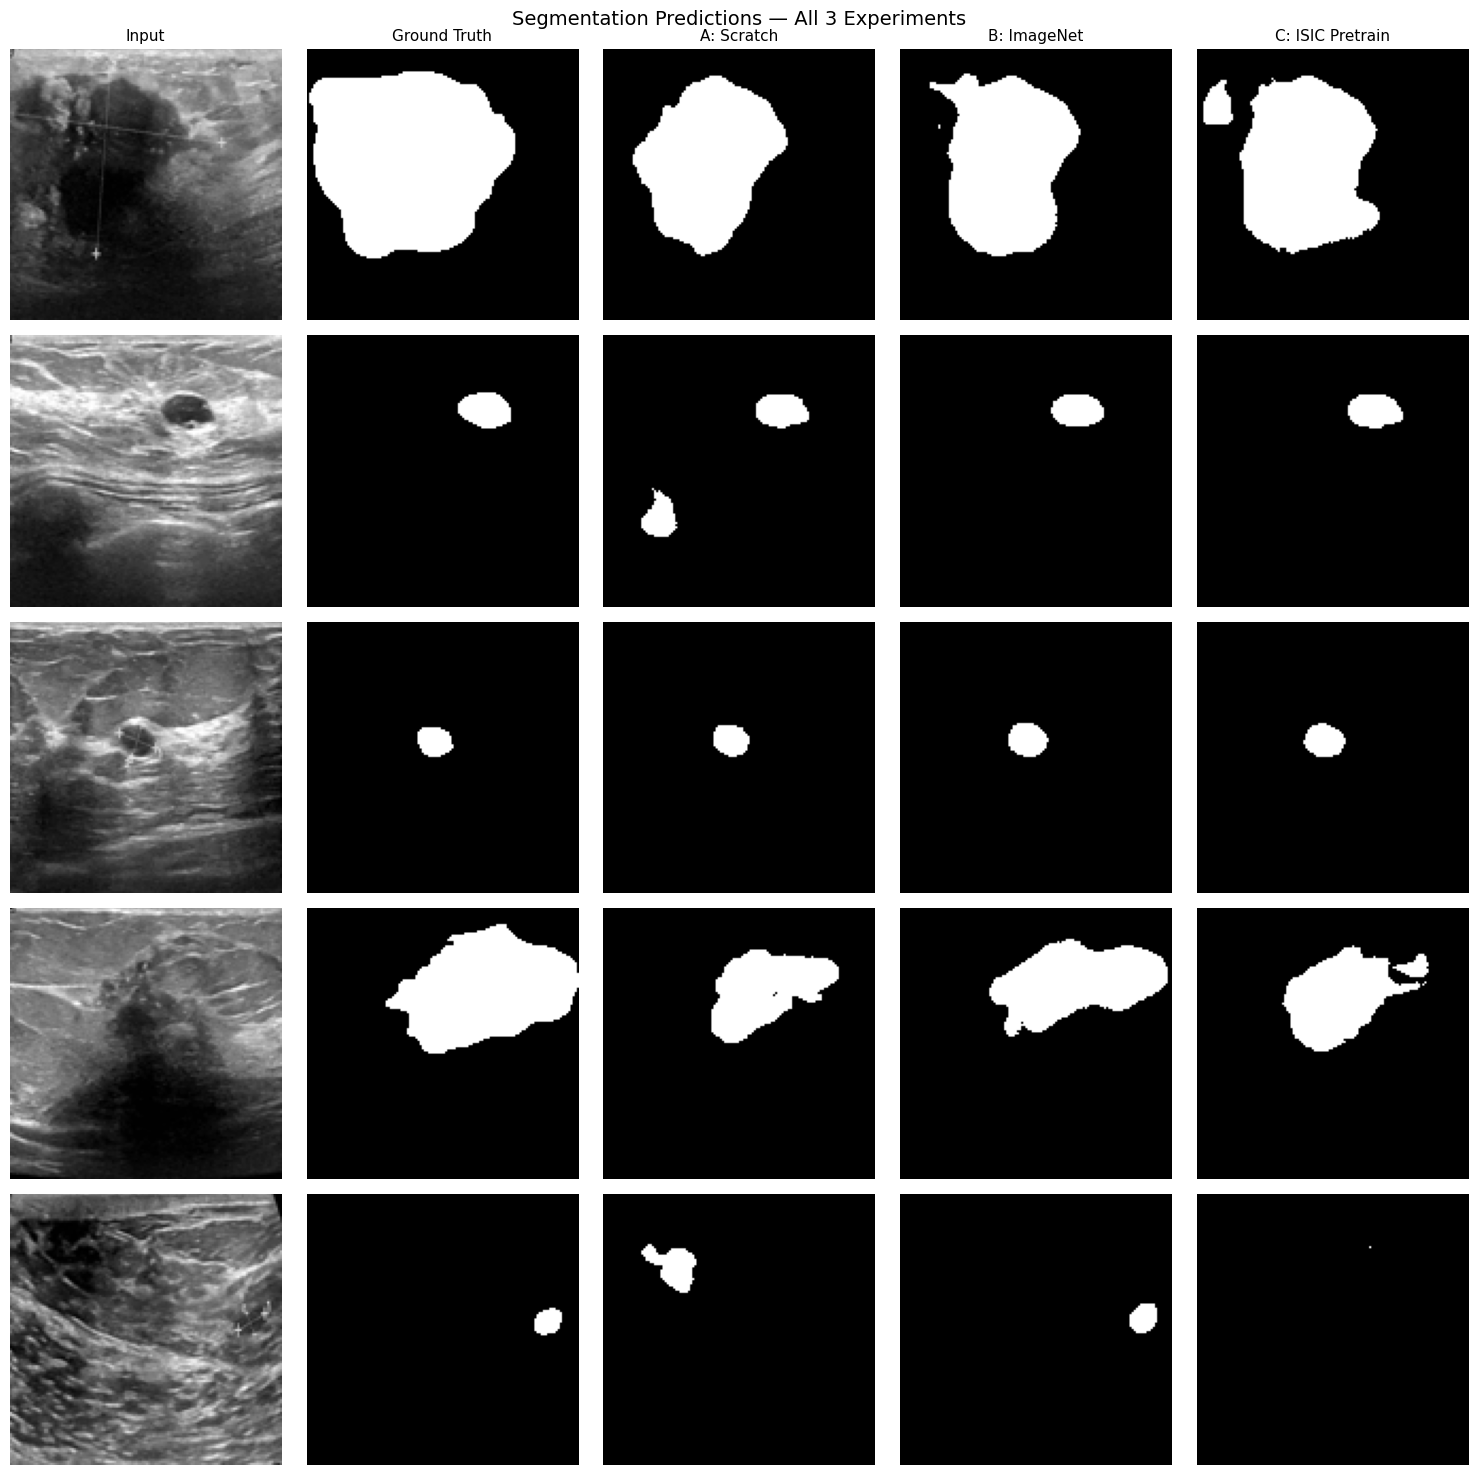

In [ ]:
# ============================================================
# Visual comparison of predictions
# ============================================================
n_show = 5
preds_A = model_A.predict(X_test[:n_show]) > 0.5
preds_B = model_B.predict(X_test[:n_show]) > 0.5
preds_C = model_C.predict(X_test[:n_show]) > 0.5

fig, axes = plt.subplots(n_show, 5, figsize=(15, 3 * n_show))
titles = ['Input', 'Ground Truth', 'A: Scratch', 'B: ImageNet', 'C: ISIC Pretrain']

for i in range(n_show):
    axes[i, 0].imshow(X_test[i])
    axes[i, 1].imshow(y_test[i,:,:,0], cmap='gray')
    axes[i, 2].imshow(preds_A[i,:,:,0], cmap='gray')
    axes[i, 3].imshow(preds_B[i,:,:,0], cmap='gray')
    axes[i, 4].imshow(preds_C[i,:,:,0], cmap='gray')
    for j in range(5):
        axes[i, j].axis('off')
        if i == 0: axes[i, j].set_title(titles[j], fontsize=11)

plt.suptitle('Segmentation Predictions — All 3 Experiments', fontsize=14)
plt.tight_layout(); plt.show()


In [ ]:
# ============================================================
# Early Stopping Summary
# ============================================================
print("EARLY STOPPING SUMMARY")
print("=" * 50)
print(f"A: Scratch    — stopped at epoch {len(history_A.history['loss'])} / {EPOCHS}")
print(f"B: ImageNet   — Phase 1: {len(history_B1.history['loss'])} ep, Phase 2: {len(history_B2.history['loss'])} ep")
print(f"C: ISIC       — Phase 1: {len(history_C1.history['loss'])} ep, Phase 2: {len(history_C2.history['loss'])} ep")
print()
print("Early stopping prevents overfitting by restoring best weights")
print("when validation loss stops improving (patience=7 epochs)")


EARLY STOPPING SUMMARY
A: Scratch    — stopped at epoch 28 / 50
B: ImageNet   — Phase 1: 14 ep, Phase 2: 13 ep
C: ISIC       — Phase 1: 13 ep, Phase 2: 13 ep

Early stopping prevents overfitting by restoring best weights
when validation loss stops improving (patience=7 epochs)


In [ ]:
# ============================================================
# NAIVE BASELINE: Single Conv2D — simplest possible model
# ============================================================
naive_model = keras.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.Conv2D(1, 1, activation='sigmoid')  # 1x1 conv, no learning capacity
])

naive_model.compile(optimizer=keras.optimizers.Adam(1e-3), loss=bce_dice_loss, metrics=[dice_coeff, iou_metric])

naive_model.fit(X_train, y_train, validation_data=(X_val, y_val),
                epochs=30, batch_size=BATCH_SIZE, callbacks=[early_stop], verbose=1)

loss_n, dice_n, iou_n = naive_model.evaluate(X_test, y_test, verbose=0)

print("\n" + "=" * 60)
print("ALL RESULTS (with Naive Baseline)")
print("=" * 60)
print(f"{'Naive Baseline':20s} | Dice: {dice_n:.4f} | IoU: {iou_n:.4f}")
print(f"{'A: Scratch':20s} | Dice: 0.7282 | IoU: 0.5952")
print(f"{'B: ImageNet':20s} | Dice: 0.7175 | IoU: 0.5986")
print(f"{'C: ISIC Pretrain':20s} | Dice: 0.7210 | IoU: 0.5831")

Epoch 1/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - dice_coeff: 0.1587 - iou_metric: 4.7102e-12 - loss: 1.4861 - val_dice_coeff: 0.1261 - val_iou_metric: 2.5464e-10 - val_loss: 1.4887
Epoch 2/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - dice_coeff: 0.1600 - iou_metric: 4.5801e-12 - loss: 1.4649 - val_dice_coeff: 0.1260 - val_iou_metric: 2.5464e-10 - val_loss: 1.4678
Epoch 3/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - dice_coeff: 0.1581 - iou_metric: 4.7410e-12 - loss: 1.4451 - val_dice_coeff: 0.1260 - val_iou_metric: 2.5464e-10 - val_loss: 1.4482
Epoch 4/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - dice_coeff: 0.1552 - iou_metric: 6.2745e-12 - loss: 1.4265 - val_dice_coeff: 0.1259 - val_iou_metric: 2.5464e-10 - val_loss: 1.4297
Epoch 5/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - dice_coeff: 0.1585 - iou_metric: 4.6721e-12 - loss: 1.4089 - val_dice_coeff: 0.1259 - val_iou_metric: 2.5464e-10 - val_loss: 1.4124
Epoch 6/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - dice_coeff: 0.1591 - iou_me